In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import pyplot

import os, sys
sys.path.append(os.path.split(os.getcwd())[0]+'/src/')
sys.path.append(os.path.split(os.getcwd())[0]+'/src/magnus')

# import magnus
import magnus.magnus as magnus
import magnus.oscprob.oscprob as oscprob
import magnus.oscprob.oscprobstd as oscprobstd
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu
import magnus.matter as matter
import magnus.globaldefs as gd

To compute neutrino oscillation proabilities, Mag$\nu$s needs only three ingredients: 
* a Hamiltonian (`H_func`), written in the flavor basis, as a function of neutrino position (or time),
* the initial neutrino position (or time, `t_ini`), and
* the final neutrino position (or time, `t_fin`).

In practice, in most scenarios the Hamiltonian depends on the neutrino energy, whose value we often vary, so the neutrino energy becomes effectively also a free parameter to vary.

Let us start by computing oscillation probabilities in vacuum in a two-neutrino system. Although the user can provide their own custom Hamiltonian, Mag$\nu$s conveniently provides a library of commonly used Hamiltonians for two-neutrino and three-neutrinos oscillations (and also for 3+1 and 3+2 systems, with one and two extra flavors, respectively).

To access the library of two-neutrino Hamiltonians, we import

In [2]:
import magnus.hamiltonians.hamiltonians2nu as hamiltonians2nu

We will use the two-neutrino Hamiltonian in vacuum, i.e.,

\begin{equation}
\mathbf{H}_{2\nu}^{\rm vac}
=
\mathbf{U}^T 
\left(
 \begin{array}{cc}
  \frac{\Delta m^2}{2E} & 0 \\
  0 & -\frac{\Delta m^2}{2E} \\
 \end{array}
\right)
\mathbf{U} \;,
\end{equation}

where the mixing matrix, $\mathbf{U}$, is parametrized by a single mixing angle, $\theta$, i.e.,

\begin{equation}
 \mathbf{U}
 =
 \left(
  \begin{array}{cc}
   \cos\theta  & \sin\theta \\
   -\sin\theta & \cos\theta
  \end{array}
 \right) \;.
\end{equation}

We need values for the oscillation parameters $\theta$ and $\Delta m^2$.  Users can provide any values they wish.  For this example, we will shows oscillations between $\nu_e$ and $\nu_mu$, and use central values of the $\theta_{12}$ and $\Delta m_{21}^2$ parameters from the NuFit 6.0 global fit to oscillation data, which are predefined in the Mag$\nu$s globaldefs module, i.e.,

In [3]:
import magnus.globaldefs as gd

sth = gd.S12_NO_BF_NUFIT_6_0 # sin(theta) [adim]
Dm2 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]

Let's compute the probability for a baseline of 10 km and an energy of 1 MeV.

In [4]:
baseline = 10.*gd.UNIT_KM # 10 km natural units [eV^{-1}]
energy = 1.*gd.UNIT_MEV # [eV]

And now we define our Hamiltonian, as a function of neutrino position (`l`) and energy (`energy`).  In this case, the dependence on neutrino position is a dummy dependence, since the Hamiltonian in vacuum is position-independent. However, Mag$\nu$s expects a position-dependent Hamiltonian in general.

In [5]:
hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2)

array([[ 7.19040000e-12, -1.72894122e-11],
       [-1.72894122e-11, -7.19040000e-12]])

The oscillation probabilities are computed using the `osc_prob` function of the `oscprob` module, which we import as

In [6]:
import magnus.oscprob.oscprobstd as oscprobstd

Internally, the `osc_prob` function performs Magnus expansion to compute the evolution of the neutrino oscillation amplitude from `t_ini` to `t_fin` by partitioning this interval into subintervals, computing the evolution operator inside each subinterval, and performing their time-ordered product. The user manipulates the options of the Magnus expansion indirectly, via parameters passed to osc_prob.

(Users interested in using Mag$\nu$s to compute the Magnus expansion of an arbitrary matrix exponential, not only in neutrino oscillations, should look at the notebook `10_magnus_matrix_exponential.ipynb`.)

The `osc_prob` function computes probabilities for *any* number of neutrino flavors.  If it is fed a $2 \times 2$ Hamiltonian, then it will return probabilities for a two-neutrino system; if it is fed a $3 \times 3$ Hamiltonian, it will return probabilities for a three-neutrino system, *etc*.

We call `osc_prob` to compute the probability from `t_ini = 0.0` to `t_fin = baseline`. We pass `verbose = 2` to see run information and warnings:

In [7]:
P = oscprob.osc_prob(hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2), 0.0, baseline, verbose=2)
P

.----------------------------------------.
|   __  __                               |
|  |  \/  | __ _  __ _ _ __  _   _ ___   |
|  | |\/| |/ _` |/ _` | '_ \| | | / __|  |
|  | |  | | (_| | (_| | | | | |_| \__ \  |
|  |_|  |_|\__,_|\__, |_| |_|\__,_|___/  |
|                |___/                   |
'----------------------------------------'
Version: 0.10

Parameters passed to function magnus.osc_prob in this run:
   H_func = constant (time-independent)
   t_ini = 0.0
   t_fin = 50677300000.0
   n_slabs = 1
   n_tpts_per_slab = 1
   n_tpts_per_slab = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = trapezoid
   rtol = 0.001
   atol = 0.001
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.5
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 2000
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 500
   validate_input = True
   save_log = False
   filename_log = ./out.log
   verbose = 2



array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

The function `osc_prob` returns a symmetric probability matrix,
\begin{equation}
 \mathbf{P}_{2\nu}
 =
 \left(
  \begin{array}{cc}
   P_{ee}    & P_{e\mu} \\
   P_{\mu e} & P_{\mu\mu}
  \end{array}
 \right) \;,
\end{equation}
where $P_{\mu e} = P_{e \mu}$.

We can select individual probabilities using flavor indices predefined in the `globaldefs` module.  I.e., for $\nu_e \to \nu_e$,

In [8]:
P[gd.NUE][gd.NUE]

0.4367802885331578

and, for $\nu_e \to \nu_\mu$,

In [9]:
P[gd.NUE][gd.NUMU]

0.5632197114668422

Notice that in the run above we had a warning.  This is because we passed a constant (*i.e.*, time-independent) Hamiltonian to `osc_prob`.  In cases like that (*i.e.*, in vacuum or constant-density matter), the only nonzero term of the Magnus expansion is the first one. *I.e.*, the evolution operator is simply $e^{-i H L}$, with $L = t_{\rm fin}-t_{\rm ini}$).  When a constant Hamiltonian is passed to `osc_prob` this is identified and the run parameters are adjusted to use first-order Magnus expansion, for speed-up.

An alternative way to compute the same probability matrix is to define a vacuum Hamiltonian function of position of neutrino position (`l`) and neutrino energy (`energy`), with the dependence on position merely dummy, since the vacuum Hamiltonian is time-independent:

In [10]:
def H_2nu_vac(l, energy):
    return hamiltonians2nu.hamiltonian_2nu_vacuum(energy, sth, Dm2)

In this case, we need to pass a Hamiltonian that is a function *only* of position:

In [11]:
oscprob.osc_prob(lambda l: H_2nu_vac(l, energy), 0.0, baseline, magnus_exp_order=1, n_slabs=1, n_tpts_per_slab=2, rtol=None, atol=None)

array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

The resulting probability matrix is the same as before, but we had to manually set tthe run parameters to generate it with the same speed as when we simply passed the constant Hamiltonian `hamiltonian_2nu_vacuum(energy, sth, Dm2)` to `osc_prob`.  However, the recipe of defining a position-dependent Hamiltonian and passing it to `osc_prob` will be at the core of later calculations of probabilities for time-*dependent* Hamiltonians.

For convenience, Mag$\nu$s includes a wrapper to return the probability matrix in vacuum for given values of the oscillation parameters, the neutrino baseline, and the neutrino energy, bypassing the more lengthy procedure above:

In [12]:
oscprob.osc_prob_2nu_vacuum(sth, Dm2, energy, baseline)

array([[0.43678029, 0.56321971],
       [0.56321971, 0.43678029]])

Let's now move on to three-neutrino oscillations.  For this, we import the predefined three-neutrino Hamiltonians as

In [13]:
import magnus.hamiltonians.hamiltonians3nu as hamiltonians3nu

The vacuum Hamiltonian is now a $3 \times 3$ matrix, i.e.,
\begin{equation}
 \mathbf{H}_{3\nu}^{\rm vac}
 =
 \mathbf{U}_{\rm PMNS}^\dagger
 \left(
  \begin{array}{ccc}
   0 & 0 & 0 \\
   0 & \frac{\Delta m_{21}^2}{2E} & 0 \\
   0 & 0 & \frac{\Delta m_{31}^2}{2E}
  \end{array}
 \right)
 \mathbf{U}_\textrm{PMNS} \;,
\end{equation}
where $\mathbf{U}_{\rm PMNS}$ is the complex-valued Pontecorvo-Maki-Nakagawa-Sakata (PMNS) matrix, parametrized using three mixing angles, $\theta_{12}$, $\theta_{23}$, and $\theta_{13}$, and one CP-violation phase, $\delta_{\rm CP}$.

Like before, for this example we set the values of the oscillation parameters to their central values from NuFit 6.0, *i.e.*,

In [14]:
s12 = gd.S12_NO_BF_NUFIT_6_0 # sin(theta_12) [adim]
s23 = gd.S23_NO_BF_NUFIT_6_0 # sin(theta_23) [adim]
s13 = gd.S13_NO_BF_NUFIT_6_0 # sin(theta_13) [adim]
dCP = gd.DCP_NO_BF_NUFIT_6_0 # [radian]
D21 = gd.D21_NO_BF_NUFIT_6_0 # [eV^2]
D31 = gd.D31_NO_BF_NUFIT_6_0 # [eV^2]

We compute the probabilities by calling `osc_prob` again. This time, we set `verbose = 1` to only show warnings and important messages:

In [15]:
P = oscprob.osc_prob(hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31), 0.0, baseline, verbose=1)
P

array([[0.44464666, 0.29867235, 0.25668099],
       [0.25107128, 0.63934947, 0.10957925],
       [0.30428206, 0.06197818, 0.63373976]])

In this case, the result is the probability matrix
\begin{equation}
 \mathbf{P}_{3\nu}
 =
 \left(
  \begin{array}{ccc}
   P_{ee}     & P_{e\mu}    & P_{e\tau} \\
   P_{\mu e}  & P_{\mu\mu}  & P_{\mu\tau} \\
   P_{\tau e} & P_{\tau\mu} & P_{\tau\tau}
  \end{array}
 \right) \;,
\end{equation}
where $P_{\alpha \beta} = P_{\beta \alpha}$, with $\alpha, \beta = e, \mu, \tau$.

We can retrieve probabilities for specific channels using flavor indices, as before, *e.g.*,

In [16]:
P[gd.NUE][gd.NUE]

0.44464666060160296

In [17]:
P[gd.NUE][gd.NUMU]

0.2986723533641969

In [18]:
P[gd.NUMU][gd.NUMU]

0.6393494679347745

In [19]:
P[gd.NUMU][gd.NUTAU]

0.10957925492166468

Similarly to the two-neutrino case, for convenience, Mag$\nu$s contains a wrapper for the calculation of the three-neutrino probability in vacuum for given values of the oscillation parameters, neutrino position, and neutrino energy:

In [20]:
oscprob.osc_prob_3nu_vacuum(s12, s23, s13, dCP, D21, D31, energy, baseline)

array([[0.44464666, 0.29867235, 0.25668099],
       [0.25107128, 0.63934947, 0.10957925],
       [0.30428206, 0.06197818, 0.63373976]])

Let's now vary the baseline and energy and plot the two- and three-neutrino $\nu_e \to \nu_\mu$ probabilities.

Text(0.5, 1.0, 'Neutrino oscillations in vacuum, $E_\\nu = $~1.00~MeV')

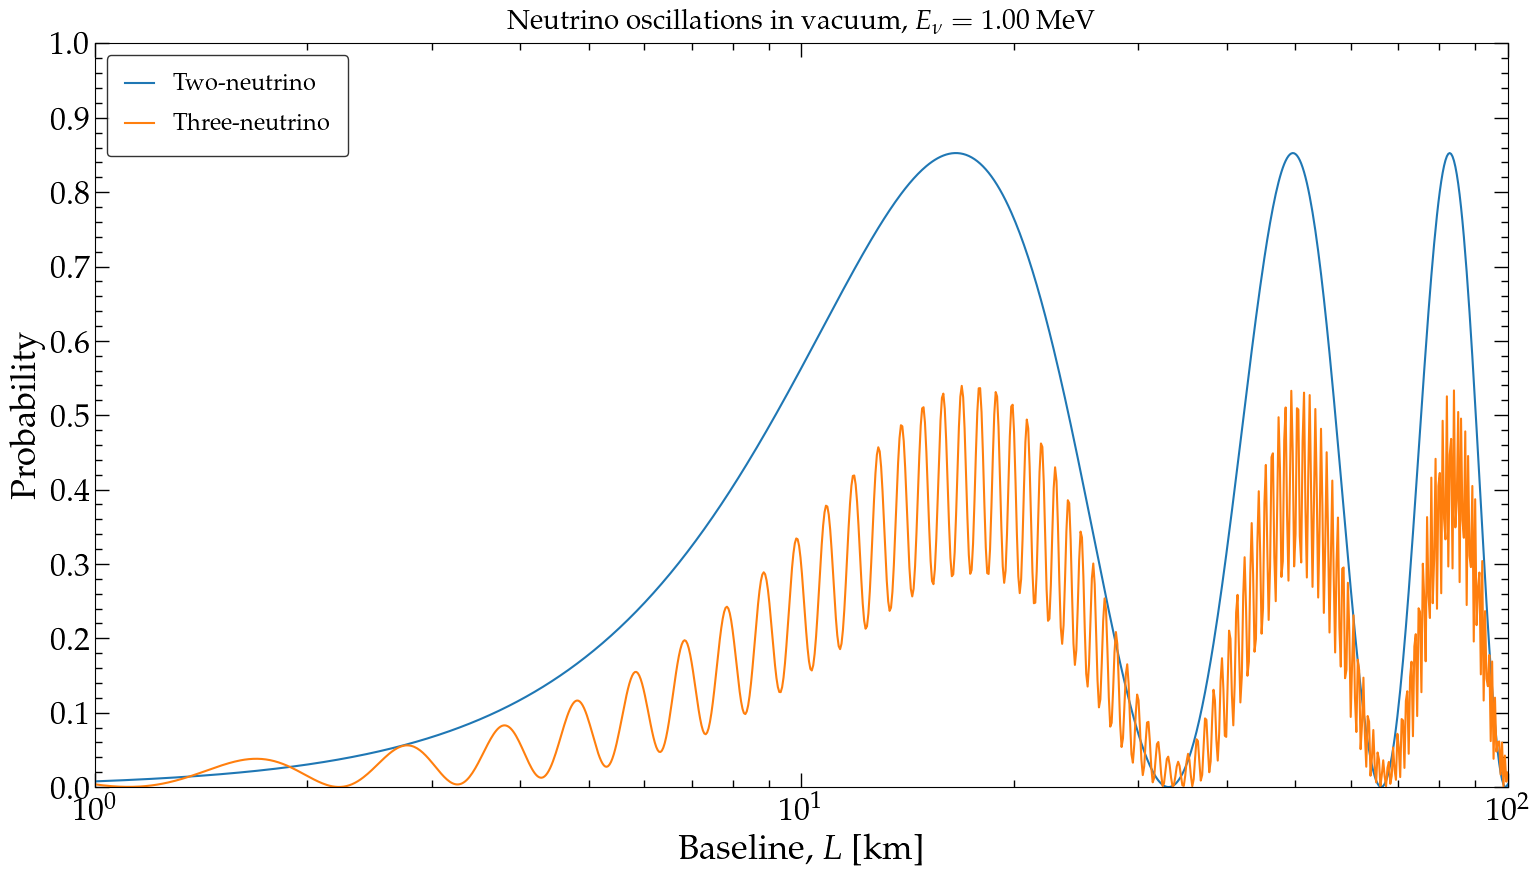

In [21]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy = 1.0*gd.UNIT_MEV # [eV]
baseline_arr = np.logspace(0.0, 2.0, npts) # [km]
prob_2nu_vacuum_arr_vs_baseline = [oscprob.osc_prob_2nu_vacuum(s12, D21, energy, l)[nu_i][nu_f] 
                                   for l in gd.UNIT_KM*baseline_arr]
prob_3nu_vacuum_arr_vs_baseline = [oscprob.osc_prob_3nu_vacuum(s12, s23, s13, dCP, D21, D31, energy, l)[nu_i][nu_f] 
                                   for l in gd.UNIT_KM*baseline_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])
ax.plot(baseline_arr, prob_2nu_vacuum_arr_vs_baseline, label=r'Two-neutrino')
ax.plot(baseline_arr, prob_3nu_vacuum_arr_vs_baseline, label=r'Three-neutrino')
ax.legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Baseline, $L$ [km]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(baseline_arr[0], baseline_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'Neutrino oscillations in vacuum, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

We can also plot probabilities *vs.* energy, say, for a fixed baseline of 100 km:

Text(0.5, 1.0, 'Neutrino oscillations in vacuum, $L = $~100.00~km')

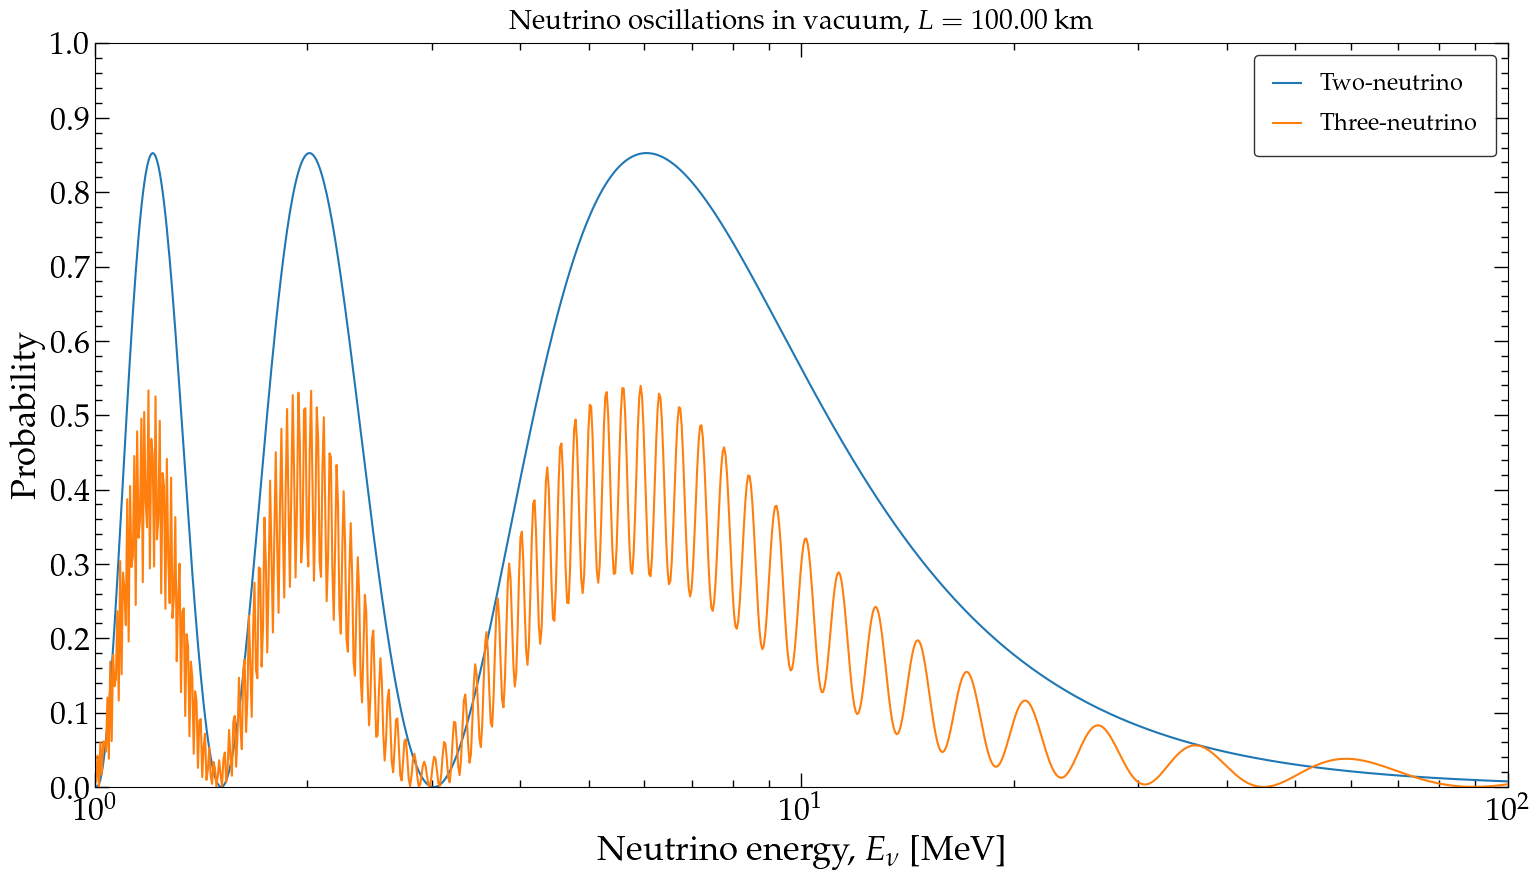

In [22]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy_arr = np.logspace(0.0, 2.0, npts) # [MeV]
baseline = 100.*gd.UNIT_KM # 100 km natural units [eV^{-1}]
prob_2nu_vacuum_arr_vs_energy = [oscprob.osc_prob_2nu_vacuum(s12, D21, energy, baseline)[nu_i][nu_f] 
                                 for energy in gd.UNIT_MEV*energy_arr]
prob_3nu_vacuum_arr_vs_energy = [oscprob.osc_prob_3nu_vacuum(s12, s23, s13, dCP, D21, D31, energy, baseline)[nu_i][nu_f] 
                                 for energy in gd.UNIT_MEV*energy_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])
ax.plot(energy_arr, prob_2nu_vacuum_arr_vs_energy, label=r'Two-neutrino')
ax.plot(energy_arr, prob_3nu_vacuum_arr_vs_energy, label=r'Three-neutrino')
ax.legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(energy_arr[0], energy_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'Neutrino oscillations in vacuum, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM), fontsize=20, pad=10)

Now let's add matter effects.  To do this, we need to add a new contribution to the Hamiltonian that contributes the potential due to the coherent forward scattering of $\nu_e$ on electrons, $V_{\rm CC}$, *i.e.*,
\begin{equation}
 H_{3\nu}^{\rm matt}
 = 
 \left(
  \begin{array}{ccc}
   V_{\rm CC} & 0 & 0 \\
   0 & 0 & 0 \\
   0 & 0 & 0 
  \end{array}
 \right) \;.
\end{equation}
With this, the total Hamiltonian becomes
\begin{equation}
 H_{3\nu} = H_{3\nu}^{\rm vac} + H_{3\nu}^{\rm matt} \;.
\end{equation}
The potential $V_{\rm CC} = \sqrt{2} G_F N_e$ varies proportionally to the electron number densit, $N_e$.

In [23]:
rho = 10 # [g cm^{-3}]

which is roughly the density at the center of the Earth.

To compute the potential given the matter density, we will need a few helper functions that are provied by Mag$\nu$s in the `matter` module, which we now import:

In [24]:
import magnus.matter as matter

First, we compute the electron number density using the `num_density_e_func` function.  This function can return the electron number density at any position given a varying matter density profile, which is why we need to pass `rho` as a position-dependent function, and evaluate at `l = 0.0` (any value of `l` will do, since `rho` is a constant).  We assume that the matter is isoscalar (*i.e.*, that the ratio of neutrons to protons is 1) and electrically neutral (*i.e.*, that the ratio of electrons to baryons, or the electron fraction, is 0.5):

In [25]:
num_density_e = matter.num_density_e_func(l=0.0, density_matter_func=lambda l: rho, 
                                          ratio_number_neutrons_to_protons=1.0, electron_fraction=0.5) # [eV^3]
num_density_e

22948286409.274242

With this, we compute the coherent forward potential using the `VCC_func` function.  Again, the function is designed to return the potential at any position given a varying electron number density profile, but we evaluate it at `l = 0`:

In [26]:
VCC = matter.VCC_func(l=0.0, num_density_e_func=lambda l: num_density_e) # [eV]
VCC

3.7853395245852554e-13

Now we can define the vacuum Hamiltonian, as before, and a constant matter contribution to the Hamiltonian using the predefined function `hamiltonian_3nu_matter`:

In [27]:
H_3nu_vac = hamiltonians3nu.hamiltonian_3nu_vacuum(energy, s12, s23, s13, dCP, D21, D31)
H_3nu_matt = hamiltonians3nu.hamiltonian_3nu_matter(VCC)
H_3nu = H_3nu_vac + H_3nu_matt

And we call the `osc_prob` function to compute the probabilities:

In [28]:
oscprob.osc_prob(H_3nu, 0.0, baseline, verbose=1)

array([[0.93733585, 0.02353004, 0.03913411],
       [0.02939153, 0.30198467, 0.66862381],
       [0.03327263, 0.67448529, 0.29224208]])

And, similarly to the two-neutrino case, for convenience, Mag$\nu$s contains a wrapper for the calculation of the three-neutrino probability in constant-density matter for given values of the oscillation parameters, neutrino position, and neutrino energy, and matter density (by default, it uses `ratio_number_neutrons_to_protons = 1.0` and `electron_fraction = 0.5`, but different values can be passed as optional arguments):

In [29]:
oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline, rho)

array([[0.93733585, 0.02353004, 0.03913411],
       [0.02939153, 0.30198467, 0.66862381],
       [0.03327263, 0.67448529, 0.29224208]])

(A similar function exists for the two-neutrino case, `osc_prob_2nu_matter_constant_density`.)

By default, this returns the probability for neutrinos.  To compute it for anti-neutrinos (which takes the complex-conjugate of the PMNS mixing matrix and flips the sign of $V_{\rm CC}$, the optional argument `nubar = True` must be passed.  *E.g.*, 

In [30]:
oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline, rho, nubar=True)

array([[0.92231588, 0.03842532, 0.0392588 ],
       [0.01602308, 0.24133653, 0.74264039],
       [0.06166104, 0.72023815, 0.21810081]])

Let's now compare three-neutrino probability of $\bar{\nu}_e \to \bar{\nu}_\mu$ in vacuum and in matter for two choices of constant matter density.  First, we plot them *vs.* baseline:

Text(0.5, 1.0, '$3\\nu$  oscillations, $E_\\nu = $~1.00~MeV')

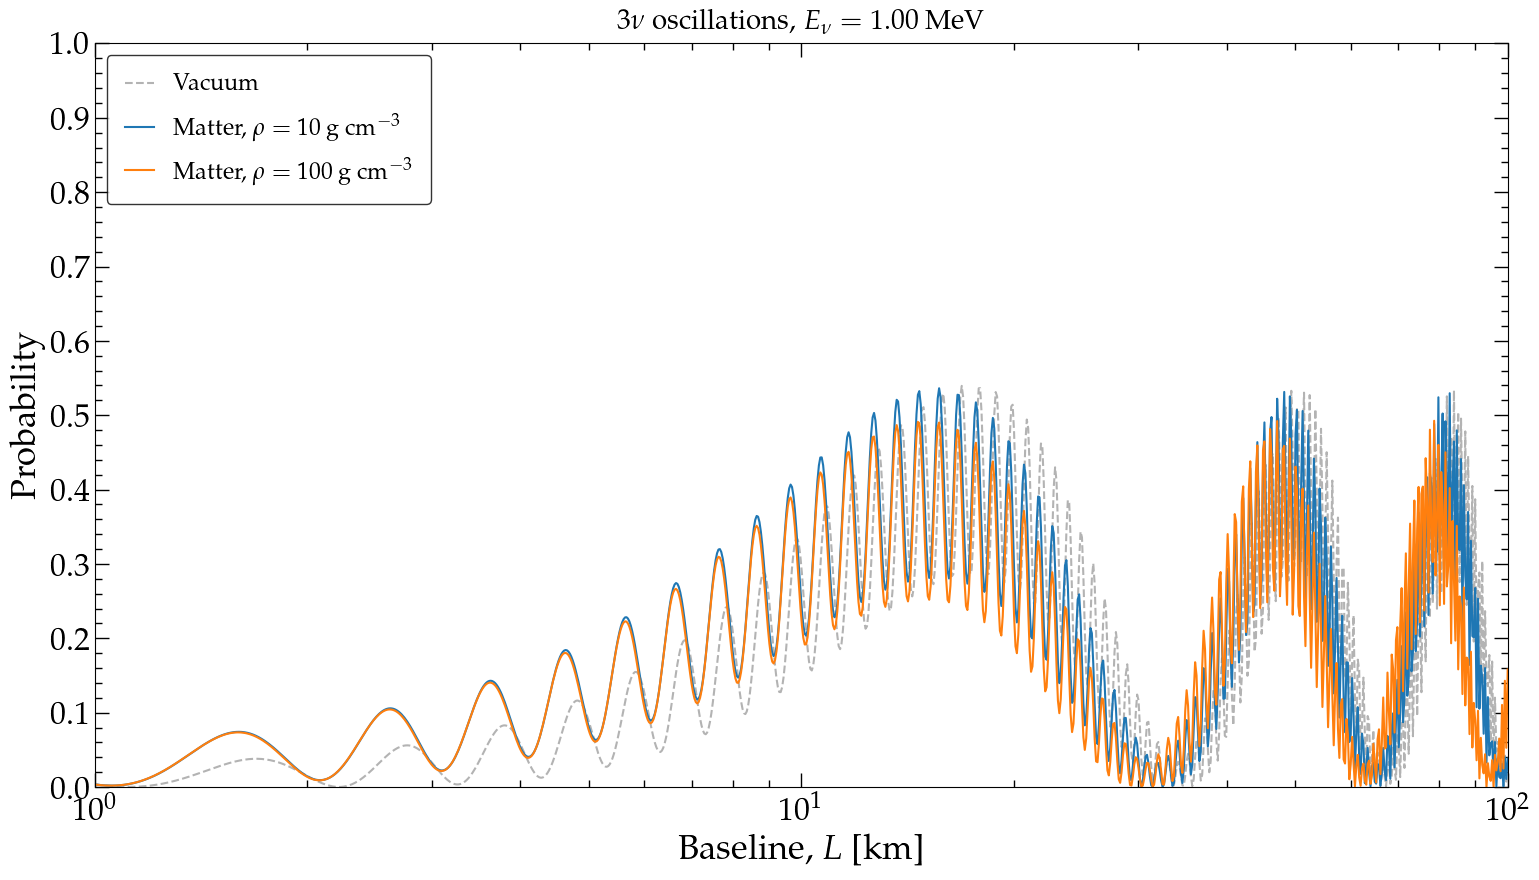

In [31]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy = 1.0*gd.UNIT_MEV # [eV]
baseline_arr = np.logspace(0.0, 2.0, npts) # [km]
rho_lo, rho_hi = 10, 100 # [g cm^{-3}]
prob_3nu_matt_const_lo_arr_vs_baseline = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, l, 
                                                                                       rho=rho_lo, nubar=True)[nu_i][nu_f] 
                                   for l in gd.UNIT_KM*baseline_arr]
prob_3nu_matt_const_hi_arr_vs_baseline = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, l, 
                                                                                       rho=rho_hi, nubar=True)[nu_i][nu_f] 
                                   for l in gd.UNIT_KM*baseline_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])
ax.plot(baseline_arr, prob_3nu_vacuum_arr_vs_baseline, label=r'Vacuum', c='0.7', ls='--')
ax.plot(baseline_arr, prob_3nu_matt_const_lo_arr_vs_baseline, label=r'Matter, $\rho = $~{:.0f}'.format(rho_lo)+r'~g~cm$^{-3}$')
ax.plot(baseline_arr, prob_3nu_matt_const_hi_arr_vs_baseline, label=r'Matter, $\rho = $~{:.0f}'.format(rho_hi)+r'~g~cm$^{-3}$')
ax.legend(fontsize=17, frameon=True, loc='upper left', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Baseline, $L$ [km]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(baseline_arr[0], baseline_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$  oscillations, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=20, pad=10)

And now we plot the probabilities *vs.* energy:

Text(0.5, 1.0, '$3\\nu$ oscillations, $L = $~100.00~km')

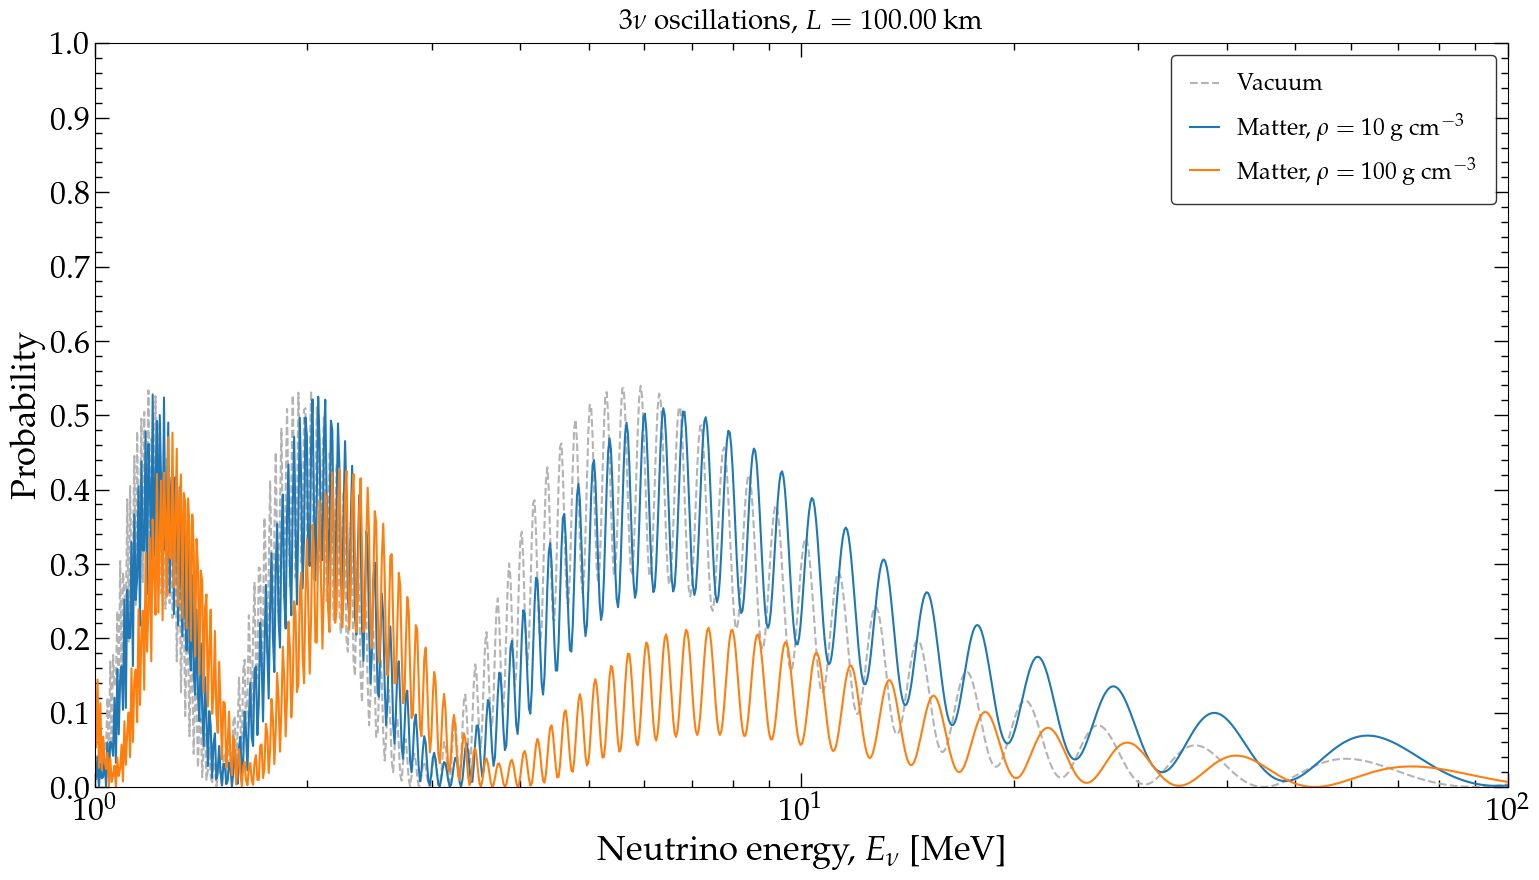

In [32]:
nu_i, nu_f = gd.NUE, gd.NUMU
npts = 1000
energy_arr = np.logspace(0.0, 2.0, npts) # [MeV]
baseline = 100.*gd.UNIT_KM # 100 km natural units [eV^{-1}]
rho_lo, rho_hi = 10, 100 # [g cm^{-3}]
prob_3nu_matt_const_lo_arr_vs_energy = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline, 
                                                                                     rho=rho_lo, nubar=True)[nu_i][nu_f] 
                                        for energy in gd.UNIT_MEV*energy_arr]
prob_3nu_matt_const_hi_arr_vs_energy = [oscprob.osc_prob_3nu_matter_constant_density(s12, s23, s13, dCP, D21, D31, energy, baseline, 
                                                                                     rho=rho_hi, nubar=True)[nu_i][nu_f] 
                                        for energy in gd.UNIT_MEV*energy_arr]

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])

ax.plot(energy_arr, prob_3nu_vacuum_arr_vs_energy, label=r'Vacuum', c='0.7', ls='--')
ax.plot(energy_arr, prob_3nu_matt_const_lo_arr_vs_energy, label=r'Matter, $\rho = $~{:.0f}'.format(rho_lo)+r'~g~cm$^{-3}$')
ax.plot(energy_arr, prob_3nu_matt_const_hi_arr_vs_energy, label=r'Matter, $\rho = $~{:.0f}'.format(rho_hi)+r'~g~cm$^{-3}$')
ax.legend(fontsize=17, frameon=True, loc='upper right', handlelength=1.2, handleheight=0.7, borderpad=0.8, 
          title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1)
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Probability')
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(energy_arr[0], energy_arr[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$ oscillations, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM), fontsize=20, pad=10)

So far, we have only computed oscillation probabilities in cases where the Hamiltonian is time-independent (or, equivalently, position-independent), *i.e.*, in vacuum and in matter with uniform density.  As we pointed out earlier, in these cases only the first term of the Magnus expansion is nonzero, and so the problem reduces to a simple one.  

Where Mag$\nu$s really shows its power and flexibility is when computing oscillation probabilities for time- or position-*dependent* Hamiltonians.  

Let's illustrate this first for a matter density profile that an exponentially falling as a function of distance, *e.g.*, like inside the Sun.

We can no longer use the pre-defined functions for oscillations in vacuum or constant-density matter (`osc_prob_3nu_matter_vacuum` and `osc_prob_3nu_matter_constant_density`), but we need to define our own Hamiltonians.  We do this by calling `hamiltonian_3nu_matter` with different profiles of matter potential.

In [33]:
# H_vac_energy_indep is the vacuum Hamiltonian without the multiplicative (1/E) factor.  Since this part will not change anymore in our
# examples below, we compute it once and save it.  (Note: in this case, we could have used the function `osc_prob_3nu_matter_vacuum` to
# compute probabilities, but we choose to compute them from scratch, as the other cases.)
H_vac_energy_indep = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(s12, s23, s13, dCP, D21, D31) # [eV^2]
def H_vac(energy):
    return (1/energy)*H_vac_energy_indep # [eV]

# In matter: exponentially falling density profile: num_density_e_center * e^{-l/l_scale}
num_density_e_center = 10*gd.N_AV/gd.UNIT_CM3 # # Central electron number density (10*N_Av cm^{-3}, converted to eV^3) [eV^3]
l_scale = 100.0 # [km]
def num_density_e_exp(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.UNIT_KM)/l_scale) # [eV^3]
def VCC_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp(r, num_density_e_center, l_scale)) # [eV]
def H_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians3nu.hamiltonian_3nu_matter(VCC_exp_density(l, num_density_e_center, l_scale))

Let's first fix the baseline to 500 km and compute the $\nu_e \to \nu_e$ survival probability.  We call `osc_prob` to compute the probabilities, like before, and pass `verbose = 2` to see the full output:

In [34]:
nu_i, nu_f = gd.NUE, gd.NUE
baseline  = 5.e2 # [km]
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2)[nu_i][nu_f]

.----------------------------------------.
|   __  __                               |
|  |  \/  | __ _  __ _ _ __  _   _ ___   |
|  | |\/| |/ _` |/ _` | '_ \| | | / __|  |
|  | |  | | (_| | (_| | | | | |_| \__ \  |
|  |_|  |_|\__,_|\__, |_| |_|\__,_|___/  |
|                |___/                   |
'----------------------------------------'
Version: 0.10

Parameters passed to function magnus.osc_prob in this run:
   H_func = <lambda>
   t_ini = 0
   t_fin = 2533865000000.0
   n_slabs = 1
   n_tpts_per_slab = 1
   n_tpts_per_slab = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = trapezoid
   rtol = 0.001
   atol = 0.001
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.5
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 2000
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 500
   validate_input = True
   save_log = False
   filename_log = ./out.log
   verbose = 2

Running loops until requested rtol and atol are achieved:
   Loop #1:
     

0.8815143837096967

By default, `osc_prob` uses fourth-order Magnus expansion (`magnus_exp_order = 4`) and returns the probability with a relative tolerance of `rtol = 1e-3` and an absolute tolerance of `atol = 1e-3`.  These values are sufficient for most purposes, but the user can change them if they so wish.

First, let's see how the probability changes for different choices of the order of the Magnus expansion (we lower the target tolerance to more clearly see it and set `verbose = 1` to print only the warnings):

In [35]:
[oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, 
                  rtol=1.e-2, atol=1.e-2, magnus_exp_order=magnus_exp_order)[nu_i][nu_f]
for magnus_exp_order in range(1,7)]

[0.8826231746652112,
 0.8826004611873592,
 0.8813001979829578,
 0.8813510302388708,
 0.8813701039777521,
 0.8814691436601084]

As we mentioned earlier, internally `osc_prob` partitions the interval from `t_ini = 0` to `t_fin = baseline` into progressively more subintervals, or slabs, and compute the time-ordered product of the evolution operator computed for each subinterval. The process is repeated until the requested target tolerance, given by `rtol` and `atol`, is reached.  

The number of slabs (`n_slabs`) grows from the minimum `min_n_slabs` (default value of `1`) up to a maximum of `max_n_slabs` (default value of `2000`). For each new partioning of the interval `[t_ini, t_fin]` interval, the number of slabs grows approximately by the approximate multiplicative factor `growth_factor_n_slabs` (default value of `1.5`).

The number of time-points inside each slab (`n_tpts_per_slab`) at which the Hamiltonian is evaluated and that are used to compute its integral inside each interval grows from the minimum `min_n_tpts_per_slab` (default value of `2`) up to a maximum of `max_n_tpts_per_slab` (default value of `500`). For each new partioning of the interval `[t_ini, t_fin]` interval, the number of time-points per slabs grows approximately by the approximate multiplicative factor `growth_factor_n_tpts_per_slab` (default value of `1.5`).

If we set `max_n_slabs` and `max_n_tpts_per_slab` to low values and attempt to compute the probability with a very high accuracy (`rtol = atol = 1.e-6`), `osc_prob` will return the result, but will issue a warning informing that the requested tolerance was not met:

In [36]:
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=2,
                 max_n_slabs=10, max_n_tpts_per_slab=10, rtol=1.e-6, atol=1.e-6)[nu_i][nu_f]

.----------------------------------------.
|   __  __                               |
|  |  \/  | __ _  __ _ _ __  _   _ ___   |
|  | |\/| |/ _` |/ _` | '_ \| | | / __|  |
|  | |  | | (_| | (_| | | | | |_| \__ \  |
|  |_|  |_|\__,_|\__, |_| |_|\__,_|___/  |
|                |___/                   |
'----------------------------------------'
Version: 0.10

Parameters passed to function magnus.osc_prob in this run:
   H_func = <lambda>
   t_ini = 0
   t_fin = 2533865000000.0
   n_slabs = 1
   n_tpts_per_slab = 1
   n_tpts_per_slab = None
   magnus_exp_order = 4
   n_jobs = 1
   integration_method = trapezoid
   rtol = 1e-06
   atol = 1e-06
   growth_factor_n_slabs = 1.5
   growth_factor_n_tpts_per_slab = 1.5
   max_num_loops = 50
   min_n_slabs = 1
   max_n_slabs = 10
   min_n_tpts_per_slab = 2
   max_n_tpts_per_slab = 10
   validate_input = True
   save_log = False
   filename_log = ./out.log
   verbose = 2

Running loops until requested rtol and atol are achieved:
   Loop #1:
      n_

0.35747621563298815

If we use the default values of these run parameters, we will achieve the high accuracy we seek:

In [37]:
oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, baseline*gd.UNIT_KM, verbose=1,
                 rtol=1.e-6, atol=1.e-6)[nu_i][nu_f]

   Requested tolerance achieved



0.8815369049607605

Now let's illustrate this for two matter density profiles that vary with position: the exponentially falling density above and a Gaussian function where most of the matter is concentrated at a certain position.  We also show results for vacuum and for constant density.

In [38]:
# In matter: constant density equal to central density 
VCC_center = matter.VCC_func(0.0, lambda l: num_density_e_center) # [eV]
H_matt_const_density = hamiltonians3nu.hamiltonian_3nu_matter(VCC_center) # [eV]
def H_const_density(energy):
    return (1/energy)*H_vac_energy_indep+H_matt_const_density # [eV]

# In matter: Gaussian density profile, centered around l_central, with width l_width
num_density_e_basal = 0*gd.N_AV/gd.UNIT_CM3 # [eV^3]
num_density_e_central = 8*gd.N_AV/gd.UNIT_CM3 # [eV^3]
l_central, l_width = 300.0, 100.0 # [km]
def num_density_e_gaussian(l, num_density_e_central, l_central, l_width):
    return num_density_e_basal+num_density_e_central*np.exp( -(l/gd.UNIT_KM-l_central)**2/(2.0*l_width**2)) # [eV^3]
def VCC_gaussian_density(l, num_density_e_central, l_central, l_width):
    return matter.VCC_func(l, lambda r: num_density_e_gaussian(r, num_density_e_central, l_central, l_width)) # [eV]
def H_gaussian_density(l, energy):
    return (1/energy)*H_vac_energy_indep  \
        + hamiltonians3nu.hamiltonian_3nu_matter(VCC_gaussian_density(l, num_density_e_central, l_central, l_width)) # [eV]

Let's first generate the $\nu_e \to \nu_e$ survival probabilities vs. baseline for a fixed energy.  To speed up the computation, we run `n_jobs = 10` parallel jobs.  Each job computes the evolution operator in a subinterval.

In [ ]:
nu_i, nu_f = gd.NUE, gd.NUE

# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 1000
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

# Compute probability vs. baseline
# osc_prob returns a 3x3 NumPy array with the probabilities: [[Pee, Pem, Pet], [Pme, Pmm, Pmt], [Pte, Ptm, Ptt]]
energy = 10.0*gd.UNIT_MEV # [eV]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(energy), 0.0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(energy), 0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# For vacuum and constant-density matter above, because we passed a time-independent Hamiltonian to `osc_prob`, we need not pass any other
# argument to it; internally, Magnus detects that is a time-independent case and adjusts the run parameters automatically for it (e.g.,
# sets the Magnus expansion to first-order only).  See comments above.

# For varying-density matter below, we need to pass to `osc_prob`, first, the Hamiltonian as a position-dependent function and, second,
# values for the run parameters to set the target accuracy with which to compute the probability.

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, l*gd.UNIT_KM, n_jobs=10)[nu_i][nu_f] 
                         for l in distances]
print('   Done\n')

# In matter: Gaussian density profile
print('Computing probabilities in matter, Gaussian density ...\n')
prob_matt_gaussian_density = [oscprob.osc_prob(lambda l: H_gaussian_density(l, energy), 0, l*gd.UNIT_KM, n_jobs=10)[nu_i][nu_f] 
                              for l in distances]
print('   Done\n')

Computing probabilities in vacuum ...

   Done

Computing probabilities in matter, constant density ...

   Done

Computing probabilities in matter, exponentially falling density ...



Now plot the probabilities vs. distance:

In [ ]:
heights = [0.3, 1.0]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center/(gd.N_AV/gd.UNIT_CM3) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_exp(l*gd.UNIT_KM, num_density_e_center, l_scale)/(gd.N_AV/gd.UNIT_CM3) \
                        for l in distances], lw=1, ls='--', c='C3')
ax[0].plot(distances, [num_density_e_gaussian(l*gd.UNIT_KM, num_density_e_central, l_central, l_width) \
                       / (gd.N_AV/gd.UNIT_CM3) for l in distances], lw=1, ls='-.', c='C5')

# Probabilities
ax[1].plot(distances, prob_vac, lw=0.5, color='0.2', ls='-', label=r'Vacuum')
ax[1].plot(distances, prob_matt_const_density, lw=1, color='C0', ls='-', label=r'Constant density')
ax[1].plot(distances, prob_matt_exp_density, lw=1, color='C3', ls='--', label=r'Exponentially falling')
ax[1].plot(distances, prob_matt_gaussian_density, lw=1, color='C5', ls='-.', label=r'Gaussian')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
for i, axx in enumerate(ax):
    axx.set_xlim(l_ini, l_fin)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
    axx.set_xscale('log')
ax[0].set_ylim(0, 11)
ax[0].xaxis.set_ticklabels([])
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=4))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=25)
ax[0].set_title(r'$3\nu$~varying-density matter, $E_\nu = $~{:.2f}~MeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[1].set_ylim(0, 1)
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$', labelpad=15)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

Let's now generate probabilities vs. energy for a fixed baseline:

In [ ]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
baseline = 1.e3*gd.UNIT_KM # 1000 km in eV^{-1} [eV^{-1}]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(enu), 0.0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(enu), 0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, enu), 0, baseline, n_jobs=10)[nu_i][nu_f] 
                         for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: Gaussian density profile
print('Computing probabilities in matter, Gaussian density ...\n')
prob_matt_gaussian_density = [oscprob.osc_prob(lambda l: H_gaussian_density(l, enu), 0, baseline, n_jobs=10)[nu_i][nu_f] 
                              for enu in gd.UNIT_MEV*energies]
print('   Done\n')

And plot them:

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])

# Probabilities
ax.plot(energies, prob_vac, lw=0.5, color='0.2', ls='-', label=r'Vacuum')
ax.plot(energies, prob_matt_const_density, lw=1, color='C0', ls='-', label=r'Constant density')
ax.plot(energies, prob_matt_exp_density, lw=1, color='C3', ls='--', label=r'Exponentially falling')
ax.plot(energies, prob_matt_gaussian_density, lw=1, color='C5', ls='-.', label=r'Gaussian')

# Legend
ax.legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$', labelpad=15)
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM), fontsize=23, pad=10)

Finally, let's  show one example of beyond-the-Standard-Model neutrino physics in the form of non-standard neutrino-matter interactions (NSI).  These interactions introduce a new matter contribution to the Hamiltonian,
\begin{equation}
 H_{3\nu}^{\rm NSI}
 = 
 V_{\rm CC}
 \left(
  \begin{array}{ccc}
   \epsilon_{ee}         & \epsilon_{e\mu}         & \epsilon_{e\tau} \\
   \epsilon_{e\mu}^\ast  & \epsilon_{\mu\mu}       & \epsilon_{\mu\tau} \\
   \epsilon_{e\tau}^\ast & \epsilon_{\mu\tau}^\ast & \epsilon_{\tau\tau}
  \end{array}
 \right) \;,
\end{equation}
where the coefficients $\epsilon_{\alpha\beta}$ set the strength of the interaction.  Their values are set by experiment.  We set them to their predefined values from `globaldefs`, but they can be set to any value. 

In [ ]:
eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt = gd.EPS_3
print(gd.EPS_3)

We test NSI using the exponentially falling matter density.  We increase the distance scale (`l_scale`) beyond which the matter profile exponentially decays, in order for the matter effects to be more evident.  We also define the Hamiltonian with NSI matter effects:

In [ ]:
l_scale = 1.e3 # [km]

def num_density_e_exp(l, num_density_e_center, l_scale):
    return num_density_e_center*np.exp(-(l/gd.UNIT_KM)/l_scale) # [eV^3]
def VCC_exp_density(l, num_density_e_center, l_scale):
    return matter.VCC_func(l, lambda r: num_density_e_exp(r, num_density_e_center, l_scale)) # [eV]

# In matter: exponentially falling density profile
def H_exp_density(l, energy):
    return (1/energy)*H_vac_energy_indep+hamiltonians3nu.hamiltonian_3nu_matter(VCC_exp_density(l, num_density_e_center, l_scale))
    
# In matter: exponentially falling density profile
def H_exp_density_nsi(l, energy): 
    return (1/energy)*H_vac_energy_indep+hamiltonians3nu.hamiltonian_3nu_nsi(VCC_exp_density(l, num_density_e_center, l_scale),
                                                                            [eps_ee, eps_em, eps_et, eps_mm, eps_mt, eps_tt])

Now we generate the probabilities vs. distance.  We choose a higher energy than before to make the matter contribution more dominant relative to the vacuum one:

In [ ]:
nu_i, nu_f = gd.NUE, gd.NUE

# Baselines
l_ini, l_fin = 5.e1, 1.e3 # [km]
l_npts = 1000 
distances = np.logspace(np.log10(l_ini), np.log10(l_fin), l_npts) # [km]

energy = 10.0*gd.UNIT_MEV # [eV]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(energy), 0.0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(energy), 0, l*gd.UNIT_KM)[nu_i][nu_f] for l in distances]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, energy), 0, l*gd.UNIT_KM, n_jobs=10)[nu_i][nu_f] 
                         for l in distances]
print('   Done\n')

# In matter: exponentially falling density profile with NSI
print('Computing probabilities in matter, exponentially falling density with NSI ...\n')
prob_matt_exp_density_nsi = [oscprob.osc_prob(lambda l: H_exp_density_nsi(l, energy), 0, l*gd.UNIT_KM, n_jobs=10)[nu_i][nu_f] 
                             for l in distances]
print('   Done\n')

And plot them:

In [ ]:
heights = [0.3, 1]
widths = [1.0]
gs_kw = dict(height_ratios=heights, width_ratios=widths)
fig, ax = plt.subplots(
    ncols=1, 
    nrows=2, 
    gridspec_kw=gs_kw, 
    figsize=[18,9])
fig.subplots_adjust(hspace=0.05, wspace=0.05)

# Density profiles
ax[0].plot(distances, [num_density_e_center/(gd.N_AV/gd.UNIT_CM3) for l in distances], lw=1, ls='-', c='C0')
ax[0].plot(distances, [num_density_e_exp(l*gd.UNIT_KM, num_density_e_center, l_scale)/(gd.N_AV/gd.UNIT_CM3) \
                        for l in distances], lw=1, ls='--', c='C3')

# Probabilities
ax[1].plot(distances, prob_vac, lw=0.5, color='0.2', ls='-', label=r'Vacuum')
ax[1].plot(distances, prob_matt_const_density, lw=1, color='C0', ls='-', label=r'Constant density')
ax[1].plot(distances, prob_matt_exp_density, lw=1, color='C3', ls='--', label=r'Exponentially falling')
ax[1].plot(distances, prob_matt_exp_density_nsi, lw=1, color='C5', ls='-.', label=r'Exponentially falling with NSI')

# Legend
ax[1].legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
             borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
for i, axx in enumerate(ax):
    axx.set_xlim(l_ini, l_fin)
    axx.grid(visible=True, c='0.8', which='both', axis='x')
    axx.grid(visible=True, c='0.8', which='major', axis='y')
    axx.set_xscale('log')
ax[0].set_ylim(0, 11)
ax[0].xaxis.set_ticklabels([])
ax[0].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=4))
ax[0].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=1))
ax[0].set_ylabel(r'$\frac{N_e}{N_{\rm Av}}$~[cm$^{-3}$]', labelpad=25)
ax[0].set_title(r'$3\nu$~varying-density matter, $E_\nu = $~{:.2f}~GeV'.format(energy/gd.UNIT_MEV), fontsize=23, pad=10)
ax[1].set_ylim(0, 1)
ax[1].set_xlabel(r'Baseline, $L$ [km]')
ax[1].set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$', labelpad=15)
ax[1].yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax[1].yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))

Finally, let's generate probabilities vs. energy for a fixed baseline:

In [ ]:
# Energies
energy_min, energy_max = 1.e0, 1.e2 # [MeV]
energy_npts = 5000
energies = np.logspace(np.log10(energy_min), np.log10(energy_max), energy_npts) # [MeV]

# Compute probability vs. energy
baseline = 5.e2*gd.UNIT_KM # 500 km in eV^{-1} [eV^{-1}]

# In vacuum
print('Computing probabilities in vacuum ...\n')
prob_vac = [oscprob.osc_prob(H_vac(enu), 0.0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: constant density equal to central density 
print('Computing probabilities in matter, constant density ...\n')
prob_matt_const_density = [oscprob.osc_prob(H_const_density(enu), 0, baseline)[nu_i][nu_f] for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density ...\n')
prob_matt_exp_density = [oscprob.osc_prob(lambda l: H_exp_density(l, enu), 0, baseline, n_jobs=10)[nu_i][nu_f] 
                         for enu in gd.UNIT_MEV*energies]
print('   Done\n')

# In matter: exponentially falling density profile
print('Computing probabilities in matter, exponentially falling density with NSI ...\n')
prob_matt_exp_density_nsi = [oscprob.osc_prob(lambda l: H_exp_density_nsi(l, enu), 0, baseline, n_jobs=10)[nu_i][nu_f] 
                             for enu in gd.UNIT_MEV*energies]
print('   Done\n')

And plot them:

In [ ]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=[18,9])

# Probabilities
ax.plot(energies, prob_vac, lw=0.5, color='0.2', ls='-', label=r'Vacuum')
ax.plot(energies, prob_matt_const_density, lw=1, color='C0', ls='-', label=r'Constant density')
ax.plot(energies, prob_matt_exp_density, lw=1, color='C3', ls='--', label=r'Exponentially falling')
ax.plot(energies, prob_matt_exp_density_nsi, lw=1, color='C5', ls='-.', label=r'Exponentially falling with NSI')

# Legend
ax.legend(fontsize=17, frameon=True, loc='lower left', handlelength=1.2, handleheight=0.7,
          borderpad=0.8, title_fontsize=20, edgecolor='k', labelspacing=0.7, ncol=1, title=r'Matter profile')

# Formatting
ax.set_xlabel(r'Neutrino energy, $E_\nu$ [MeV]')
ax.set_ylabel(r'Survival probability, $P_{\nu_e \to \nu_e}$', labelpad=15)
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(base=0.10))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(base=0.02))
ax.set_xlim(energies[0], energies[-1])
ax.set_ylim(0, 1)
ax.set_xscale('log')
ax.set_title(r'$3\nu$~varying-density matter, $L = $~{:.2f}~km'.format(baseline/gd.UNIT_KM), fontsize=23, pad=10)